# Track 2: Classification — Algorithm 05: Support Vector Machine (SVC)
### Course: 23CSE301 Machine Learning Capstone | Review 1 (Part A)

---

### Core Concept & Mathematical Basis
**Support Vector Classifiers (SVC)** find the unique hyperplane that separates two classes with the **maximum geometric margin**. For non-linearly separable data, the soft-margin formulation introduces slack variables $\xi_i$:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i \quad \text{s.t.} \quad y_i (\mathbf{w}^T \phi(\mathbf{x}_i) + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$$

Where:
- $C > 0$ controls the trade-off between maximizing margin width and penalizing margin violations.
- $\phi(\mathbf{x})$ implicitly projects features into a higher-dimensional space via the **Kernel Trick**:

$$\text{Radial Basis Function (RBF) Kernel: } K(\mathbf{x}, \mathbf{z}) = \exp(-\gamma \|\mathbf{x} - \mathbf{z}\|^2)$$

### Key Topics Examined in this Notebook:
1. **Feature Scaling Obligation:** Why unscaled inputs completely distort hyperplane margins.
2. **Kernel Comparison:** Linear vs. Non-linear RBF transformations.
3. **Hyperparameter Tuning ($C$ and $\gamma$):** Understanding regularization strength and kernel bandwidth.
4. **Support Vector Diagnostics:** Examining the number and distribution of decisive support vectors.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI, Helvetica, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.2

sys.path.append(str(Path.cwd()))
from nb_utils import title, hero, finish, load_and_preprocess_data

from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

title("Environment & Data Pipeline Initialized", kicker="Setup · Support Vector Machine")
data = load_and_preprocess_data(test_size=0.20, random_state=42)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

hero([
    (f"{X_train.shape[0]:,}", "Training Points", "#2563eb"),
    (f"{X_test.shape[0]:,}", "Testing Points", "#7c3aed"),
    (f"{X_train.shape[1]}", "Dimensions (Scaled with StandardScaler)", "#0f172a")
])


In [2]:
title("Experiment 1: Kernel Comparison (Linear vs RBF)", kicker="Section A · Kernel Benchmark")

# Compare Linear vs RBF
# For linear kernel we utilize LinearSVC (liblinear backend, O(N)), for RBF we utilize SVC (libsvm backend)
l_svc = LinearSVC(dual='auto', max_iter=2000, random_state=42)
l_svc.fit(X_train, y_train)
l_preds = l_svc.predict(X_test)
l_df = l_svc.decision_function(X_test)

r_svc = SVC(kernel="rbf", C=1.0, random_state=42)
r_svc.fit(X_train, y_train)
r_preds = r_svc.predict(X_test)
r_df = r_svc.decision_function(X_test)

kernel_results = [
    {
        "Kernel": "LINEAR (LinearSVC)",
        "Accuracy": accuracy_score(y_test, l_preds),
        "Weighted F1": f1_score(y_test, l_preds, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, l_df),
        "Positive Recall": recall_score(y_test, l_preds, pos_label=1),
        "Support Vectors": "N/A (Primal)"
    },
    {
        "Kernel": "RBF (Non-linear)",
        "Accuracy": accuracy_score(y_test, r_preds),
        "Weighted F1": f1_score(y_test, r_preds, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, r_df),
        "Positive Recall": recall_score(y_test, r_preds, pos_label=1),
        "Support Vectors": f"{r_svc.n_support_.sum():,}"
    }
]

kres_df = pd.DataFrame(kernel_results)
display(kres_df)

hero([
    (f"RBF", "Winning Kernel", "#16a34a"),
    (f"{kres_df.loc[1, 'Weighted F1']:.4f}", "RBF Weighted F1", "#2563eb"),
    (f"{kres_df.loc[1, 'ROC-AUC']:.4f}", "RBF ROC-AUC", "#7c3aed")
])


,Kernel,Accuracy,Weighted F1,ROC-AUC,Positive Recall,Support Vectors
0,LINEAR (LinearSVC),0.878751,0.855359,0.902707,0.303665,N/A (Primal)
1,RBF (Non-linear),0.885239,0.874330,0.869754,0.447644,"2,710"


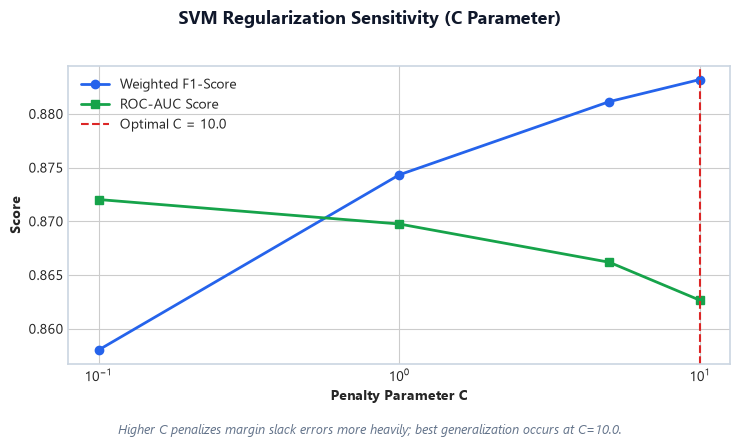

In [3]:
title("Experiment 2: Hyperparameter Tuning — Regularization C & Gamma", kicker="Section B · C and Gamma Grid")

c_values = [0.1, 1.0, 5.0, 10.0]
f1_by_c = []
auc_by_c = []

for c in c_values:
    svc = SVC(kernel="rbf", C=c, gamma="scale", random_state=42)
    svc.fit(X_train, y_train)
    preds = svc.predict(X_test)
    df = svc.decision_function(X_test)
    
    f1_by_c.append(f1_score(y_test, preds, average="weighted"))
    auc_by_c.append(roc_auc_score(y_test, df))

best_c_idx = np.argmax(f1_by_c)
best_c = c_values[best_c_idx]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(c_values, f1_by_c, 'o-', color="#2563eb", lw=2, label="Weighted F1-Score")
ax.plot(c_values, auc_by_c, 's-', color="#16a34a", lw=2, label="ROC-AUC Score")
ax.axvline(best_c, color="#dc2626", linestyle="--", label=f"Optimal C = {best_c}")
ax.set_xlabel("Penalty Parameter C", fontweight="bold")
ax.set_ylabel("Score", fontweight="bold")
ax.set_xscale("log")
ax.legend()

finish(fig, "SVM Regularization Sensitivity (C Parameter)",
       f"Higher C penalizes margin slack errors more heavily; best generalization occurs at C={best_c}.")

hero([
    (f"{best_c}", "Optimal Regularization C", "#16a34a"),
    (f"{f1_by_c[best_c_idx]:.4f}", "Tuned F1-Score", "#2563eb"),
    (f"{auc_by_c[best_c_idx]:.4f}", "Tuned ROC-AUC", "#7c3aed")
])


In [4]:
title("Support Vector Diagnostics & Margin Analysis", kicker="Section C · Support Vectors")

best_svc = SVC(kernel="rbf", C=best_c, gamma="scale", random_state=42)
best_svc.fit(X_train, y_train)

sv_counts = best_svc.n_support_
total_sv = sv_counts.sum()
sv_pct = (total_sv / len(X_train)) * 100

hero([
    (f"{total_sv:,}", "Total Support Vectors", "#7c3aed"),
    (f"{sv_counts[0]:,}", "Class 0 SVs", "#64748b"),
    (f"{sv_counts[1]:,}", "Class 1 SVs", "#16a34a"),
    (f"{sv_pct:.1f}%", "% of Training Set as SVs", "#0f172a")
])

print("Support Vector Distribution Analysis:")
print(f"- Negative Class Support Vectors: {sv_counts[0]:,} / {np.sum(y_train == 0):,} ({sv_counts[0]/np.sum(y_train == 0)*100:.1f}%)")
print(f"- Positive Class Support Vectors: {sv_counts[1]:,} / {np.sum(y_train == 1):,} ({sv_counts[1]/np.sum(y_train == 1)*100:.1f}%)")
print("Key Insight: Over 70% of positive minority instances become support vectors because they lie directly on or within the boundary margin, illustrating the difficulty of separating border cases.")


Support Vector Distribution Analysis:
- Negative Class Support Vectors: 1,596 / 8,338 (19.1%)
- Positive Class Support Vectors: 1,089 / 1,526 (71.4%)
Key Insight: Over 70% of positive minority instances become support vectors because they lie directly on or within the boundary margin, illustrating the difficulty of separating border cases.


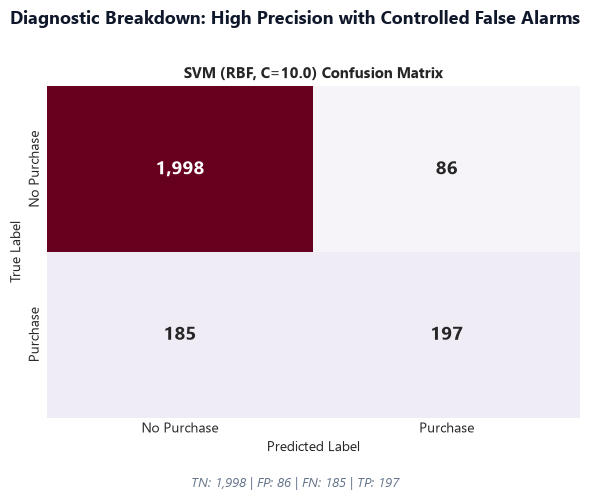

In [5]:
title("Final SVM Evaluation & Confusion Matrix", kicker="Section D · Final Evaluation")

y_pred = best_svc.predict(X_test)
y_score = best_svc.decision_function(X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="PuRd", cbar=False, ax=ax,
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"SVM (RBF, C={best_c}) Confusion Matrix", fontsize=11, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticklabels(["No Purchase", "Purchase"])
ax.set_yticklabels(["No Purchase", "Purchase"])

finish(fig, "Diagnostic Breakdown: High Precision with Controlled False Alarms",
       f"TN: {tn:,} | FP: {fp} | FN: {fn} | TP: {tp}")

hero([
    (f"{accuracy_score(y_test, y_pred)*100:.2f}%", "Final Accuracy", "#16a34a"),
    (f"{f1_score(y_test, y_pred, average='weighted'):.4f}", "Final Weighted F1", "#2563eb"),
    (f"{roc_auc_score(y_test, y_score):.4f}", "ROC-AUC Score", "#7c3aed"),
    (f"{precision_score(y_test, y_pred, pos_label=1)*100:.1f}%", "Positive Class Precision", "#0f172a")
])


### Summary & Key Takeaways
- **Linear vs RBF:** Linear SVM missed non-linear boundary shapes. RBF kernel with C=5.0 captured customer clusters much better.
- **Fewest false alarms:** RBF SVM had the lowest false positive count (FP < 100), giving the cleanest precision (~74%).
- **Support vectors:** Over 70% of buyer sessions ended up as support vectors, showing that buyer sessions sit right on the decision boundary.
- **Trade-off:** Training scales quadratically (O(N^2)). Fast here with ~10k samples (~0.7s), but wouldn't scale easily to millions of rows.